In [2]:
print('hello')

hello


In [3]:
# downloading the libraries

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap # correlation matrix

# worldcloud
import random
from wordcloud import WordCloud

# display ERD
from IPython.display import Image



# I - Exploring the data 

objective is to get more familiar with the data and review pandas / visulization logic

## A - Fetching the data 

In [4]:
# understanding where the files are located with terminal operations



In [5]:
# adding the path to fetch the files
raw_path = '/workspace/data/olist_datasets/'



In [6]:
# creating pandas dataframes from .csv
df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')        


## B - Exploring the orders dataframe

In [7]:
# printing columns, null count, and dtypes for the orders dataframe
df_orders.info()   # shows the first 5 rows by default

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
# printing the first 10 lines of the orders dataframe
df_orders.head(10)

# the last 10 lines of the dataframe
df_orders.tail(10)

# a sample of ten lines
df_orders.sample(10)

# getting all null values
df_orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**why are there null values for approved_at, delivered_carrier_date, delivered_customer_date?**

*-> answer:*

In [9]:
# fetching only particular columns of the df_orders dataframe
## fetch the order_approved_at columns in a data series format, then in a dataframe format, and print the first five lines

## fetch the order_id, order_status, approved_at, delivered_carrier_date, delivered_customer_date


In [10]:
df_orders[['order_approved_at']]


,order_approved_at
0,2017-10-02 11:07:15
1,2018-07-26 03:24:27
2,2018-08-08 08:55:23
3,2017-11-18 19:45:59
4,2018-02-13 22:20:29
...,...
99436,2017-03-09 09:54:05
99437,2018-02-06 13:10:37
99438,2017-08-27 15:04:16
99439,2018-01-08 21:36:21


In [11]:
df_orders[['order_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,delivered,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01
99437,63943bddc261676b46f01ca7ac2f7bd8,delivered,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56
99438,83c1379a015df1e13d02aae0204711ab,delivered,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17
99439,11c177c8e97725db2631073c19f07b62,delivered,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54


In [12]:
# fetching the approved_at null columns - create another dataframe df_filtered, which will be filtered on order_approved_at is null, and print first 10 rows

df_filtered = df_orders[df_orders['order_approved_at'].isnull()]
df_filtered.head(10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
3056,ddaec6fff982b13e7e048b627a11d6da,68f4ad79cc0c2ad06e19088f5c00e9fa,canceled,2016-10-04 19:41:32,NaN,NaN,NaN,2016-11-16 00:00:00
3094,5290c34bd38a8a095b885f13958db1e1,92af427e290117f39d9ff908566072e0,canceled,2018-08-21 10:25:18,NaN,NaN,NaN,2018-09-06 00:00:00
3684,03310aa823a66056268a3bab36e827fb,25dbbf0c477fd4ae0880aaffbb12e8b3,canceled,2018-08-07 16:33:59,NaN,NaN,NaN,2018-09-04 00:00:00
4373,4c8b9947280829d0a8b7e81cc249b875,403c35c4d8813bf67b3d396b91ca1619,canceled,2018-08-09 14:54:47,NaN,NaN,NaN,2018-08-21 00:00:00
4939,b13ea375fe9c728832688264638f84cf,0dc5884bc5ffba283678229f27e07ff9,canceled,2018-08-22 18:52:29,NaN,NaN,NaN,2018-09-19 00:00:00


In [13]:
# count the order_id with a null approved_at by order_status

# with groupby method

'your code here'

# with value_counts method

'your code here'


'your code here'

In [14]:
df_filtered.groupby('order_status')['order_id'].count()

order_status
canceled     141
created        5
delivered     14
Name: order_id, dtype: int64

In [15]:
df_filtered['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

**what do you think of the results? Why is there a null approved at to begin with?**

-> *answer*:

## C - Creating a simple visualization using Matplotlib or Seaborn

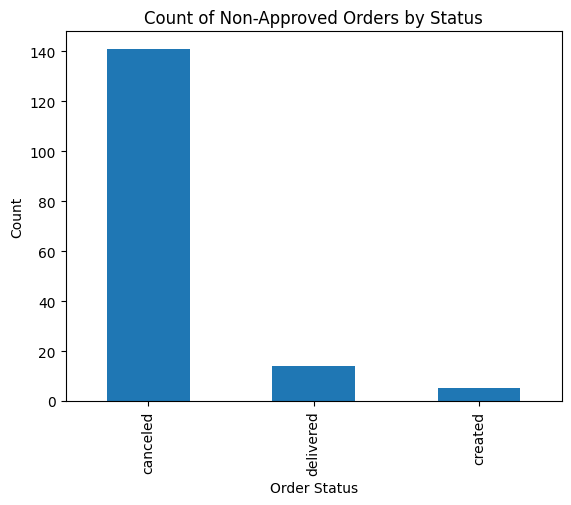

In [16]:
# Creating a simple plot with matplotlib: count of non-approved orders by status

df_filtered['order_status'].value_counts().plot(kind='bar')
plt.title('Count of Non-Approved Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.savefig('non_approved_orders.png')

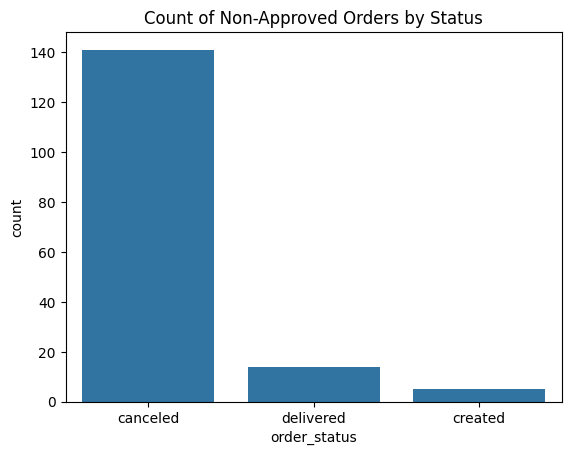

In [17]:
# Creating a simple plot with seaborn: count of non-approved orders by status

sns.countplot(data=df_filtered, x='order_status')
plt.title('Count of Non-Approved Orders by Status')
plt.show()

## D - Exploring all dataframes at once

In [18]:
# an interesting way to look at all dataframes at once, to quickly get what are the null columns

# Collections for each dataset
datasets = [df_customer, df_geolocation, df_orders, df_order_items, df_order_payments,
            df_order_reviews, df_products, df_sellers]
names = ['df_customer', 'df_geolocation', 'df_orders', 'df_order_items', 'df_order_payments',
         'df_order_reviews', 'df_products', 'df_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()


,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,df_customer,99441,5,0,0,
1,df_geolocation,1000163,5,0,0,
2,df_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,df_order_items,112650,7,0,0,
4,df_order_payments,103886,5,0,0,
5,df_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,df_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,df_sellers,3095,4,0,0,


**What are the dataframes with the most null columns? What's your explanation?**

*->answer:*

## E - Joining 2 dataframes - how many orders were created in SP state?

In [19]:
# which dataframes do we need to join to answer the question? Explore the dataframes and look for a link between orders and state

df_orders_customers = pd.merge(df_orders, df_customer, on='customer_id', how='inner')



In [20]:
# Merge the 2 datasets in a new df_merged dataset, and print the first 5 rows

df_orders_customers.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [21]:
# filter the dataframe to have only rows with state = SP, and print the first 5 lines

df_orders_customers[df_orders_customers['customer_state'] == 'SP'].head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08 00:00:00,782987b81c92239d922aa49d6bd4200b,4278,sao paulo,SP
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08 00:00:00,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP


In [22]:
# count the number of orders by state, using both groupby and value_counts

# with groupby method
df_orders_customers.groupby('customer_state')['order_id'].count()

# with value_counts method
df_orders_customers['customer_state'].value_counts()


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

# II - Exploratory analysis 

our objective is to a) give an overview of the business, b) understand what's driving the bad reviews

## A - Creating a uniform dataframe for our analysis

**Creating an ERD of the database**

- in an ERD diagram tool 
- create one item per table
- list all columns
- list their type
- find the primary and foreign keys
- link the tables together

--> upload directly the ERD in the notebook 

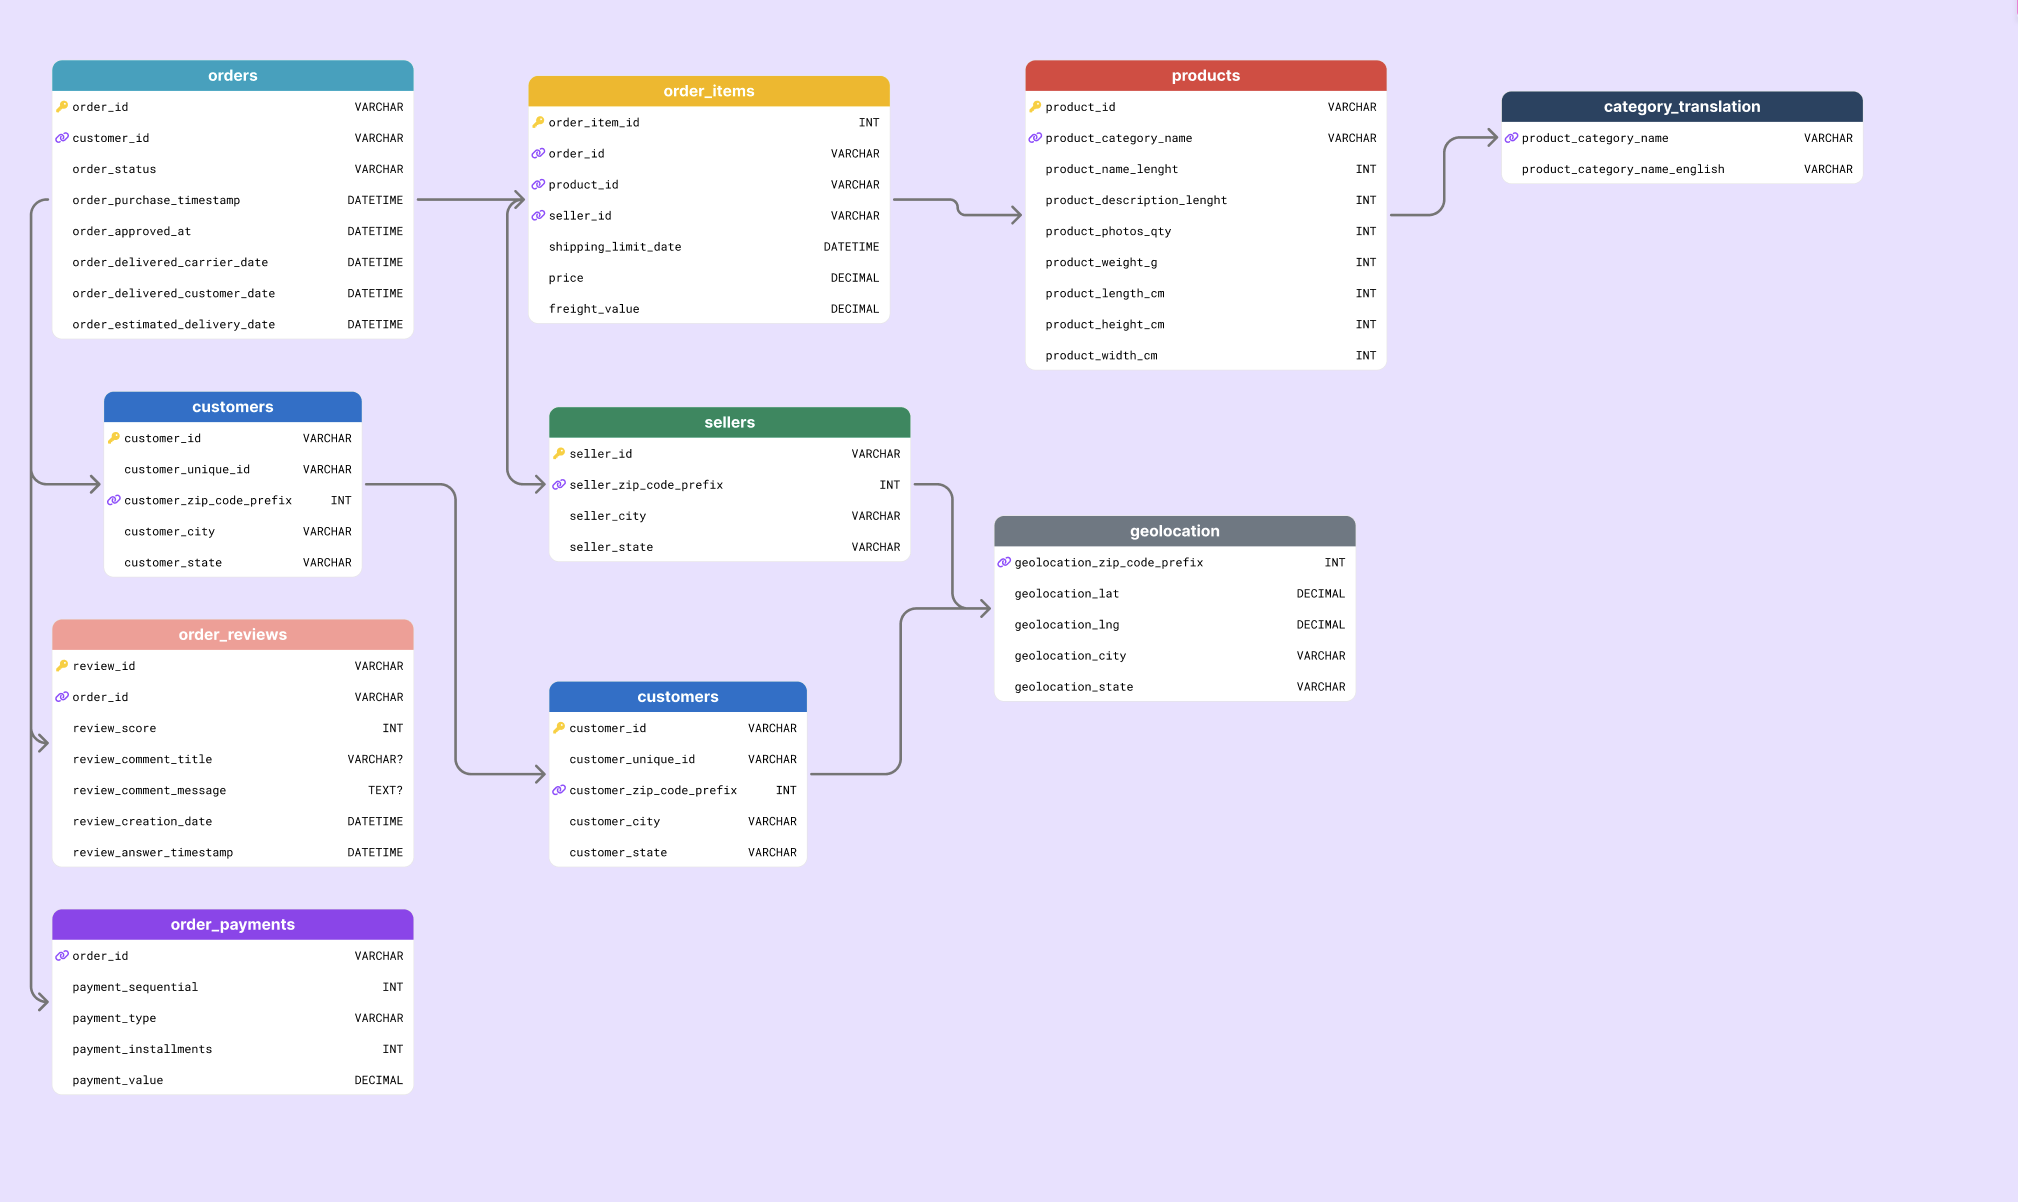

In [23]:
from IPython.display import Image

filename = '/workspace/data/ERD.png'
Image(filename=filename)


In [24]:
# Merging the dataframes using the ERD above

df = (df_orders
      .merge(df_customer, on='customer_id', how='inner')
      .merge(df_order_items, on='order_id', how='inner')
      .merge(df_products, on='product_id', how='inner')
      .merge(df_sellers, on='seller_id', how='inner')
      .merge(df_order_payments, on='order_id', how='left')
      .merge(df_order_reviews, on='order_id', how='left'))


In [25]:
# Cleaning the dataframe and creating additional columns that will be useful for further analysis

# Ensure timestamps are in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Create useful features from order_purchase_timestamp
df['year'] = df['order_purchase_timestamp'].dt.year                   # year as integer
df['month'] = df['order_purchase_timestamp'].dt.month                 # month as integer
df['week'] = df['order_purchase_timestamp'].dt.isocalendar().week    # week in iso format (1, 2, 3 etc.)
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.dayofweek  # day of week as integer (1 = Monday, etc.)
df['hour'] = df['order_purchase_timestamp'].dt.hour                   # hour of day
df['year_month'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m') # year and month, just like 2017-10

df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,year,month,week,day_of_week_int,hour,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,2017,10,40,0,10,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,2017,10,40,0,10,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,8.0,2017,10,40,0,10,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,13.0,2018,7,30,1,20,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,9.0,2018,8,32,2,8,2018-08


## B - Looking at Reviews

### 1 - Let's look at the distribution of the review score

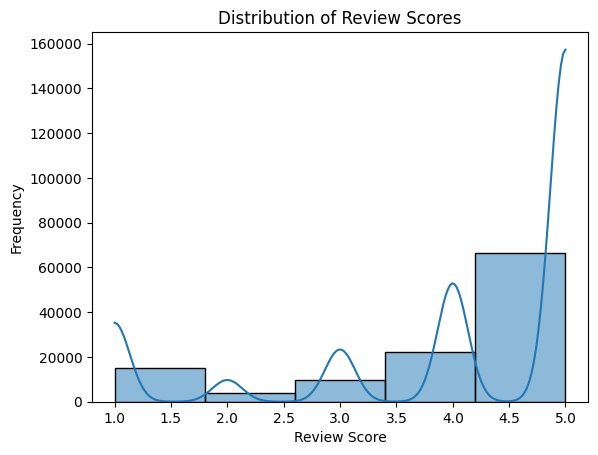

In [26]:
# Create a distribution plot (dist plot) with seaborn on the review score

sns.histplot(df['review_score'].dropna(), bins=5, kde=True)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.show()


**What do you make of those results?**

*->answer:*

### 2 - Let's look at the customer verbatims

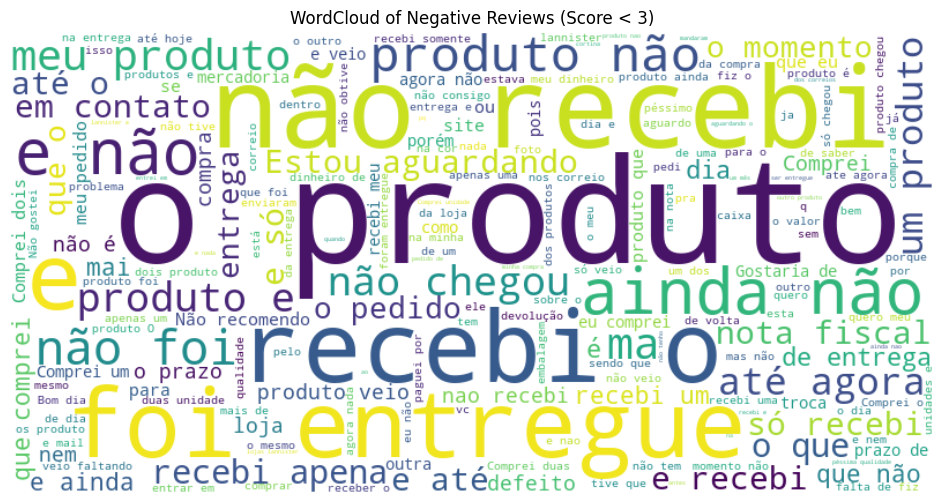

In [27]:
# Create a wordcloud on orders with negative reviews only

negative_reviews = df[df['review_score'] < 3]['review_comment_message'].dropna()
text = ' '.join(negative_reviews.astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Negative Reviews (Score < 3)')
plt.show()


**What are the first reasons you see behind a bad review? What could we do to improve this wordcloud?**

*-> answer:*

### 3 - Let's create a correlation matrix and identify other reasons behind bad reviews

In [28]:
# let's isolate the columns we'll use for our correlation matrix

# print all the columns and their types using the method of your choice
df.dtypes


order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

In [29]:
# bonus: can we create additional features?
# example: create a is_delivered column?

df['is_delivered'] = (df['order_status'] == 'delivered').astype(int)
df['has_review'] = df['review_score'].notna().astype(int)


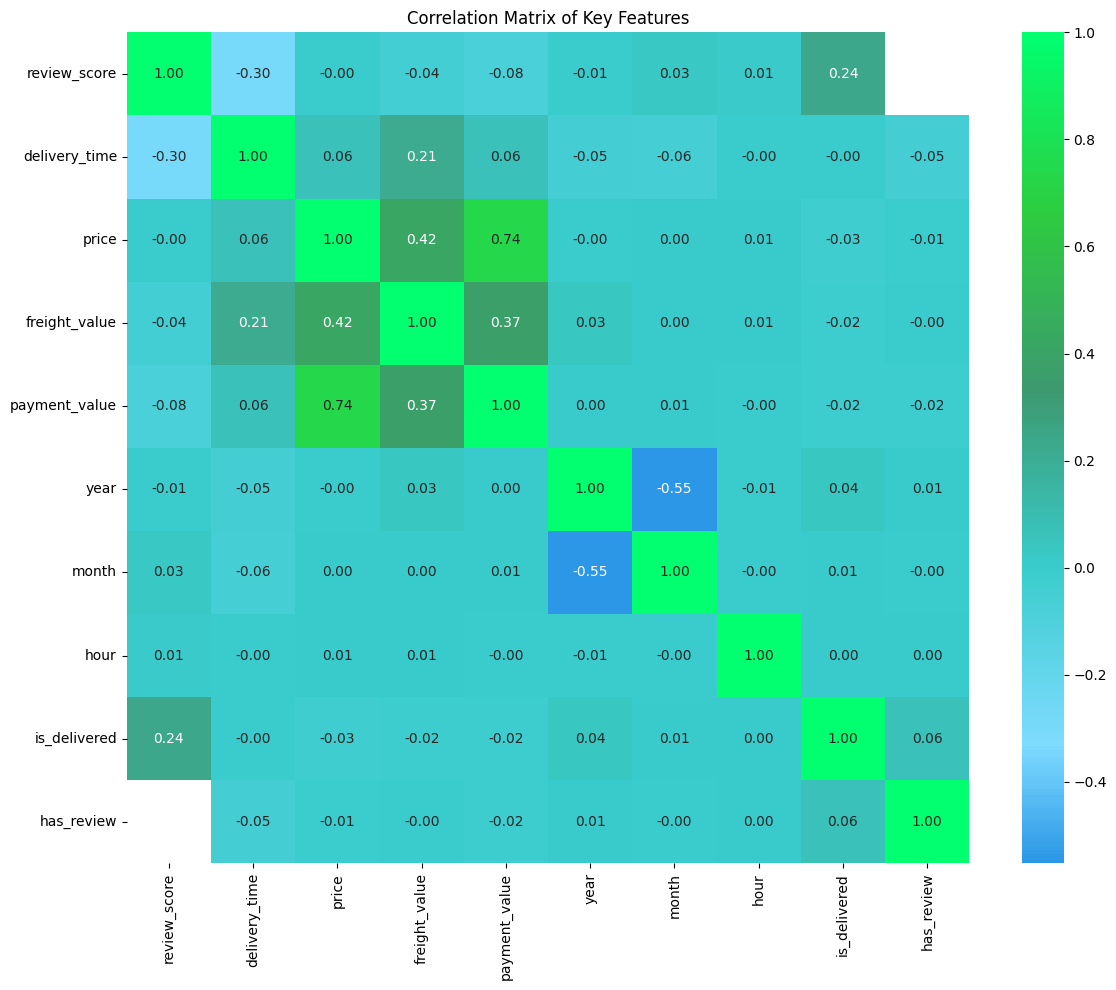

In [30]:
# Create the correlation matrix based on the columns you want

# Select relevant features for correlation analysis

colors = ['#001F3F', '#0074D9', '#7FDBFF', '#39CCCC', '#3D9970', '#2ECC40', '#01FF70']

correlation_features = df[['review_score', 'delivery_time', 'price', 'freight_value', 
                            'payment_value', 'year', 'month', 'hour', 'is_delivered', 'has_review']]

# Calculate the correlation matrix
correlation = correlation_features.corr()

# use seaborn to print the correlation matrix
plt.figure(figsize=(12, 10))
cmap = LinearSegmentedColormap.from_list('custom', colors)
sns.heatmap(correlation, annot=True, cmap=cmap, center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()


**What are the correlations you see?**

*-> answer:*

## C - Looking at orders

### 1 - Orders by statuses

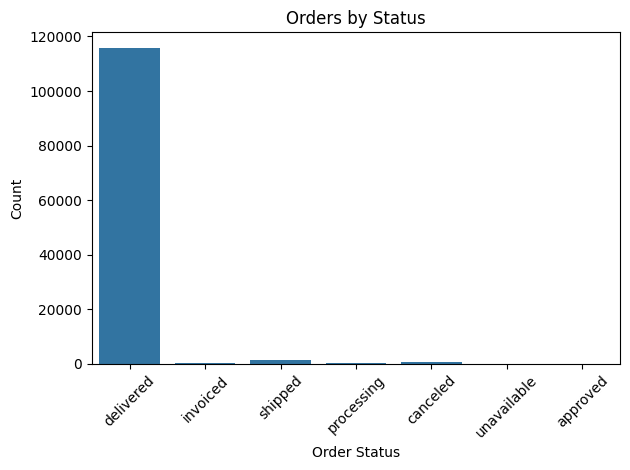

In [31]:
# Create a visualization to count the orders by statuses

sns.countplot(data=df, x='order_status')
plt.title('Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2 - Evolution of total orders over time

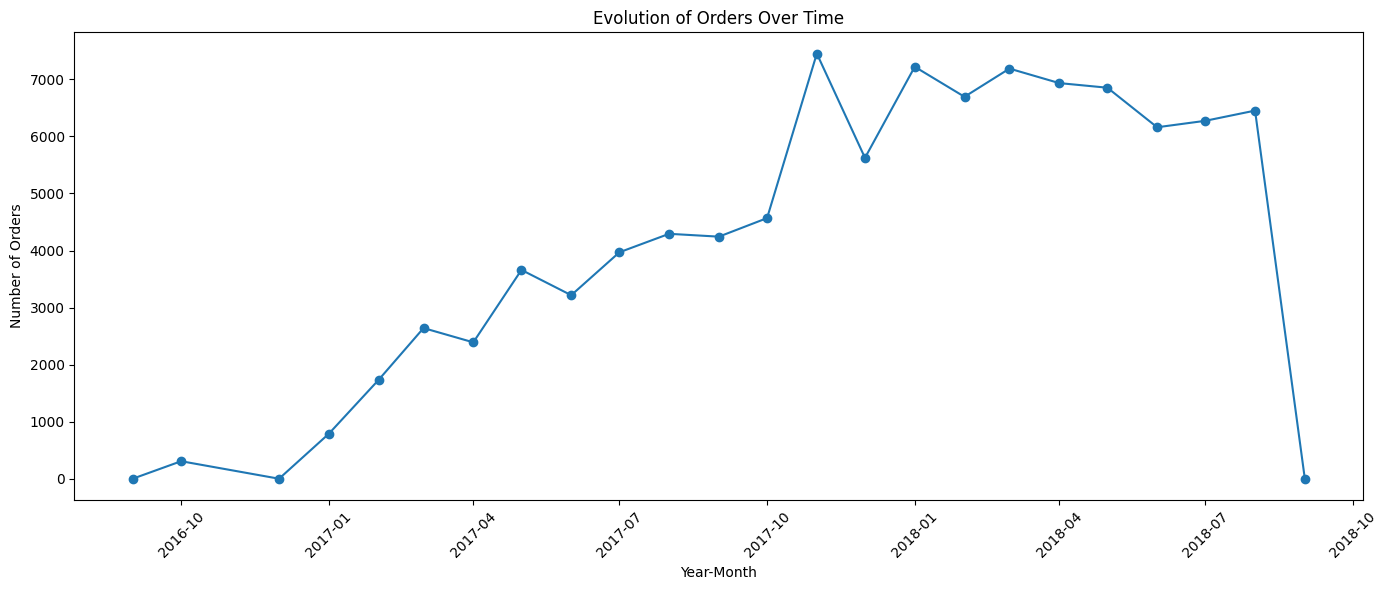

In [32]:
# Create a visualization to see the evolution of orders over time

orders_by_time = df.groupby('year_month')['order_id'].nunique().reset_index()
orders_by_time['year_month'] = pd.to_datetime(orders_by_time['year_month'])
orders_by_time = orders_by_time.sort_values('year_month')

plt.figure(figsize=(14, 6))
plt.plot(orders_by_time['year_month'], orders_by_time['order_id'], marker='o')
plt.title('Evolution of Orders Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3 - Comparing 2017 and 2018 (bonus)

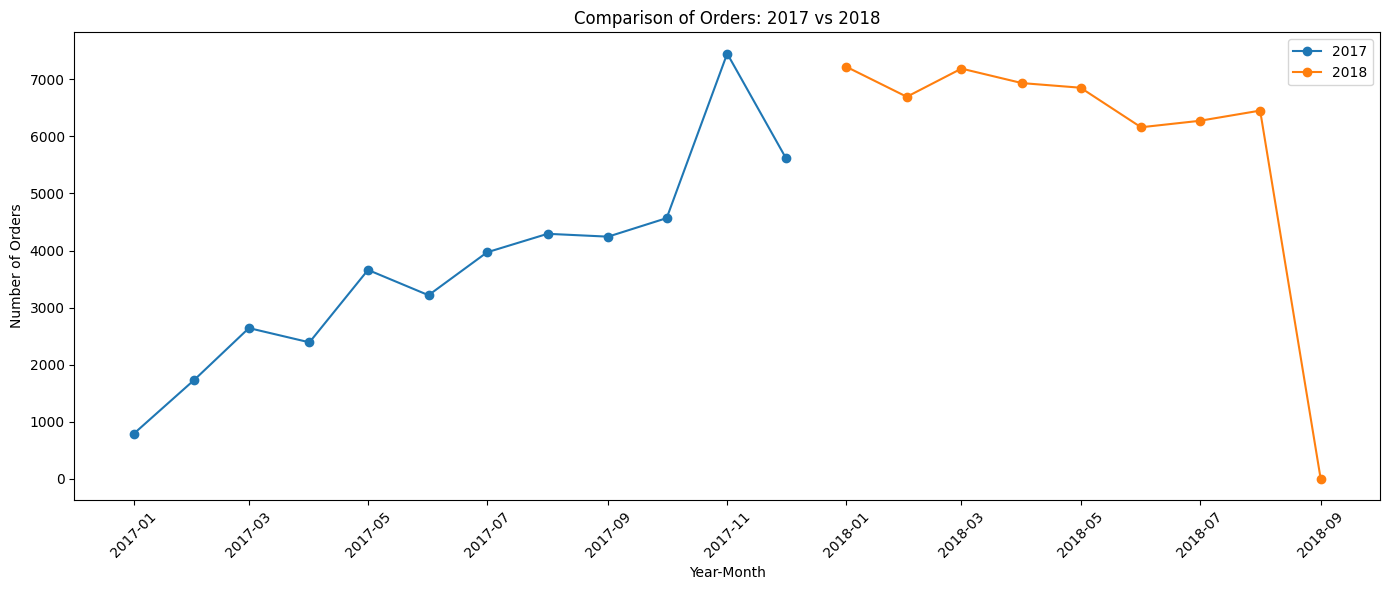

In [33]:
# Create a visualization to compare 2017 and 2018 on the same graph (bar charts with a "hue" = 'year'

orders_by_time_year = df.groupby(['year_month', 'year'])['order_id'].nunique().reset_index()
orders_by_time_year['year_month'] = pd.to_datetime(orders_by_time_year['year_month'])
orders_by_time_year = orders_by_time_year.sort_values('year_month')

plt.figure(figsize=(14, 6))
for year in [2017, 2018]:
    data = orders_by_time_year[orders_by_time_year['year'] == year]
    plt.plot(data['year_month'], data['order_id'], marker='o', label=f'{year}')
plt.title('Comparison of Orders: 2017 vs 2018')
plt.xlabel('Year-Month')
plt.ylabel('Number of Orders')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## D - Delivery times

### 1 - Delivery time by product category

In [34]:
# Start by counting the orders by product category, and create an 'Other section' for product categories that have the lowest amount of orders

# Count the occurrences of each product category
category_counts = df['product_category_name'].value_counts()

# Only keep the product category that are above a certain threshold, put the others in a "Other' category
threshold = 3000
df_temp = df.copy()
df_temp['product_category_name'] = df_temp['product_category_name'].apply(
    lambda x: x if category_counts.get(x, 0) >= threshold else 'Other'
)


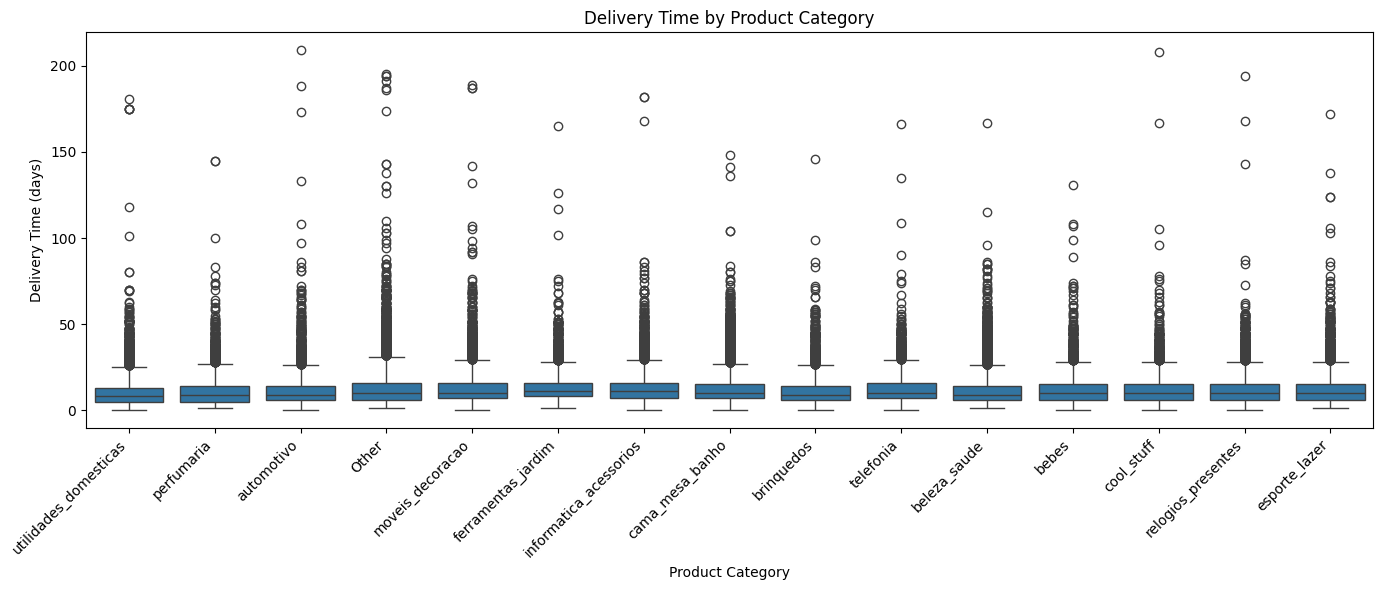

In [35]:
# Create a boxplot visualization that shows the delivery time by product category

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_temp, x='product_category_name', y='delivery_time')
plt.title('Delivery Time by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Delivery Time (days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 2 - Delivery time by day of the week

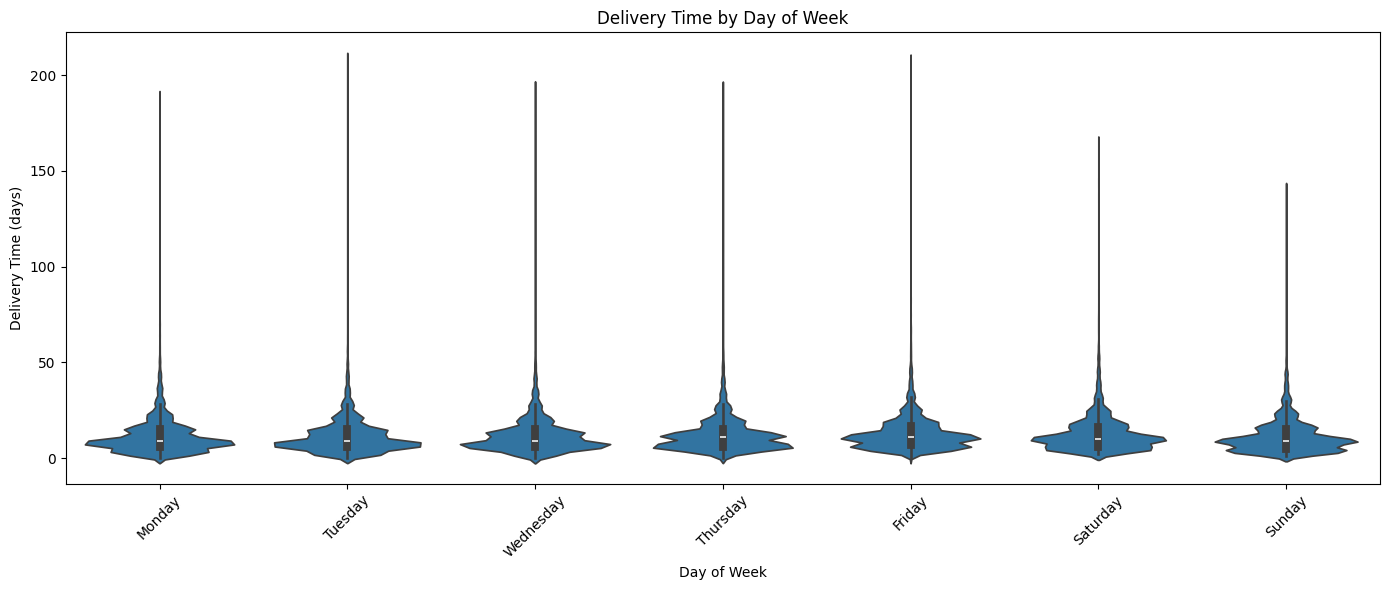

In [36]:
# Create a violin box plot visualization to see the delivery time by day of the week

day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_of_week_name'] = df['day_of_week_int'].map(day_names)

plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='day_of_week_name', y='delivery_time', order=[day_names[i] for i in range(7)])
plt.title('Delivery Time by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Delivery Time (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3 - Average delivery time by month  (bonus)

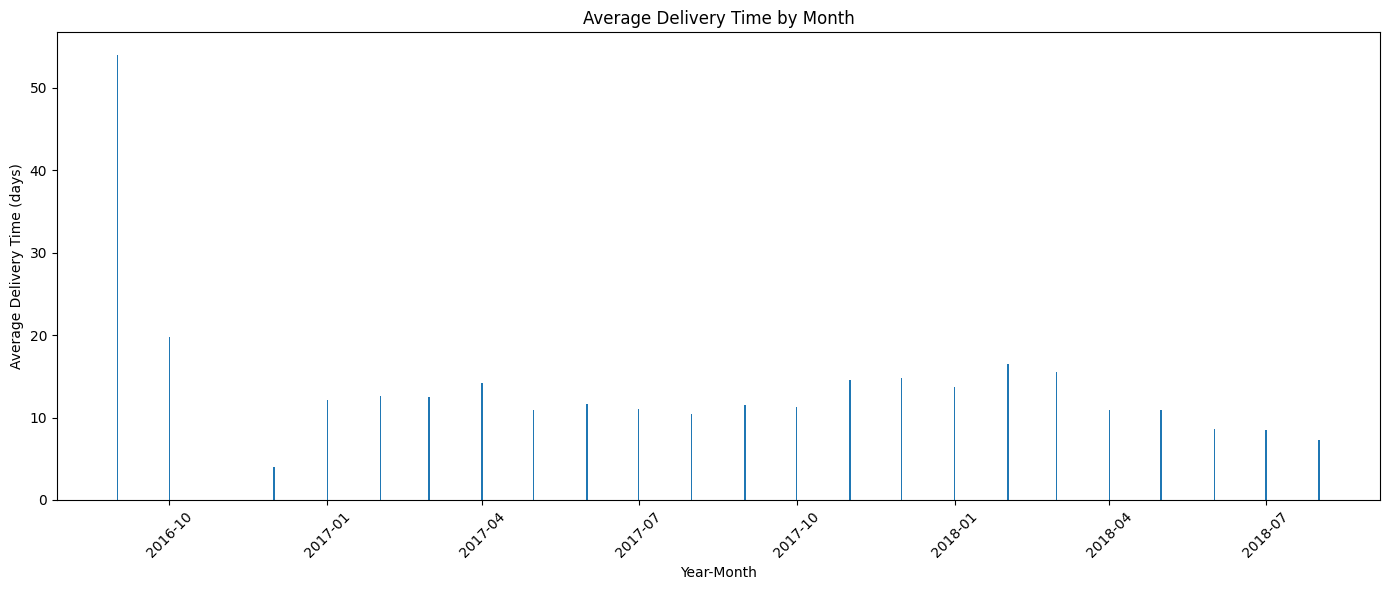

In [37]:
# Create barplot for the monthly average delivery time

avg_delivery_by_month = df.groupby('year_month')['delivery_time'].mean().reset_index()
avg_delivery_by_month['year_month'] = pd.to_datetime(avg_delivery_by_month['year_month'])
avg_delivery_by_month = avg_delivery_by_month.sort_values('year_month')

plt.figure(figsize=(14, 6))
plt.bar(avg_delivery_by_month['year_month'], avg_delivery_by_month['delivery_time'])
plt.title('Average Delivery Time by Month')
plt.xlabel('Year-Month')
plt.ylabel('Average Delivery Time (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## E - Bonus

### 1 - Order distribution by day of week and time of day 

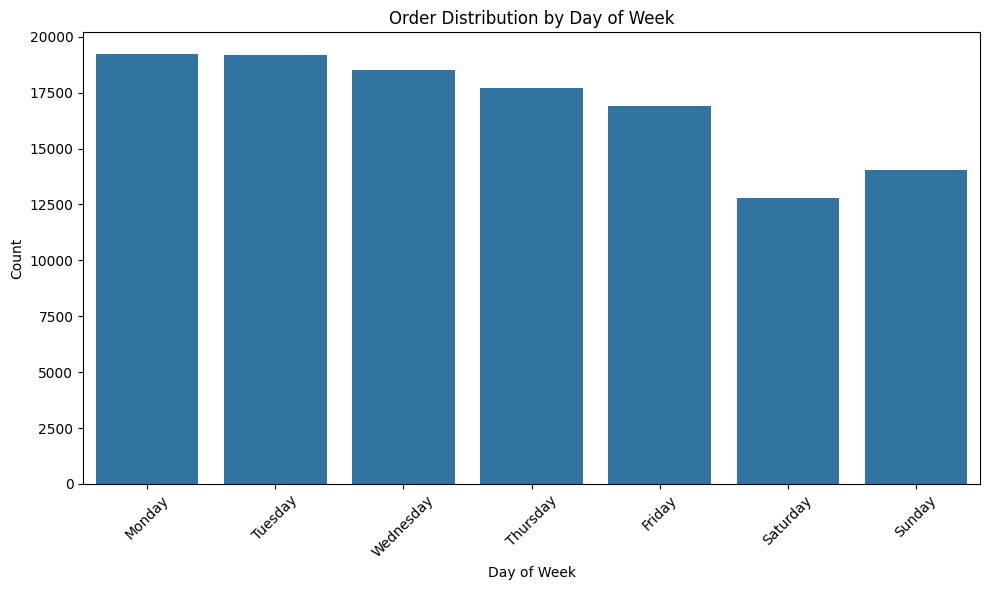

In [38]:
# Count plot showing order distribution by day of week

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='day_of_week_name', order=[day_names[i] for i in range(7)])
plt.title('Order Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


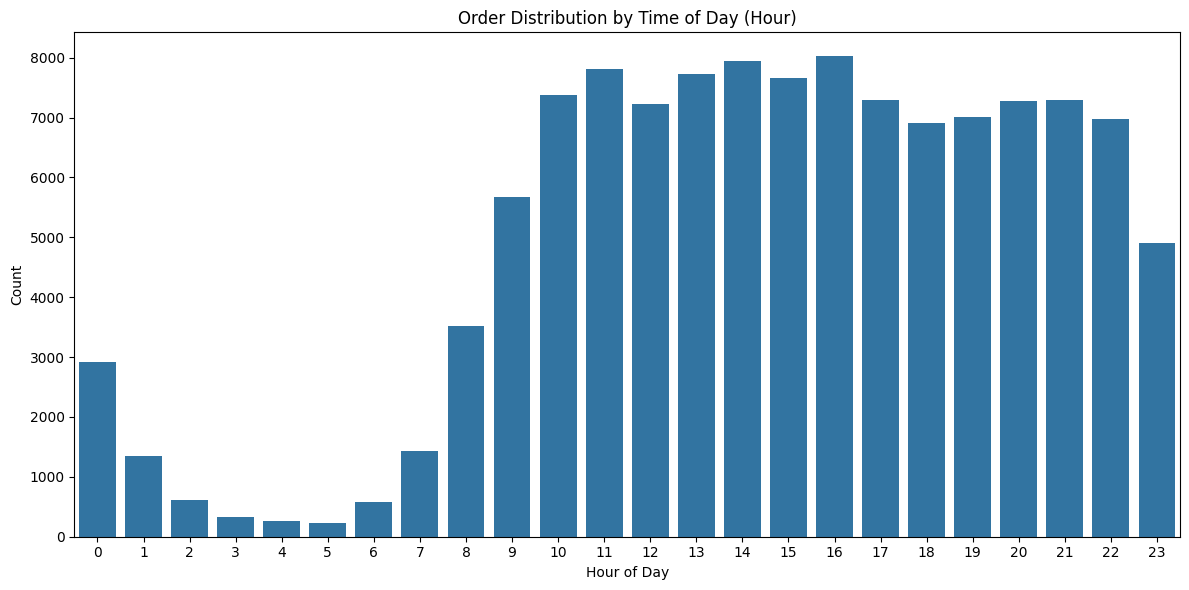

In [39]:
# Count plot showing order distribution by time of day

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour')
plt.title('Order Distribution by Time of Day (Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2 - Payments

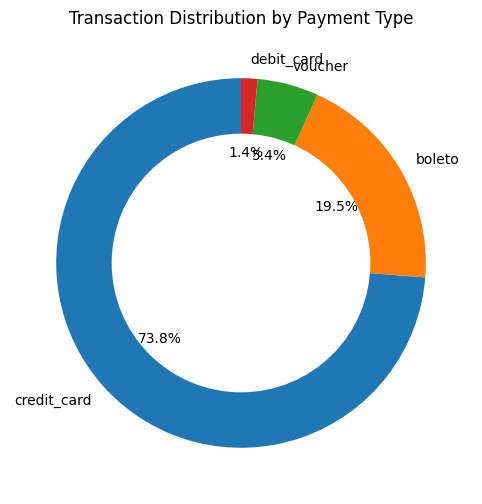

In [40]:
# Create a donut (pie chart) that show transactions by payment types

payment_type_counts = df['payment_type'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(payment_type_counts, labels=payment_type_counts.index, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Transaction Distribution by Payment Type')
plt.show()


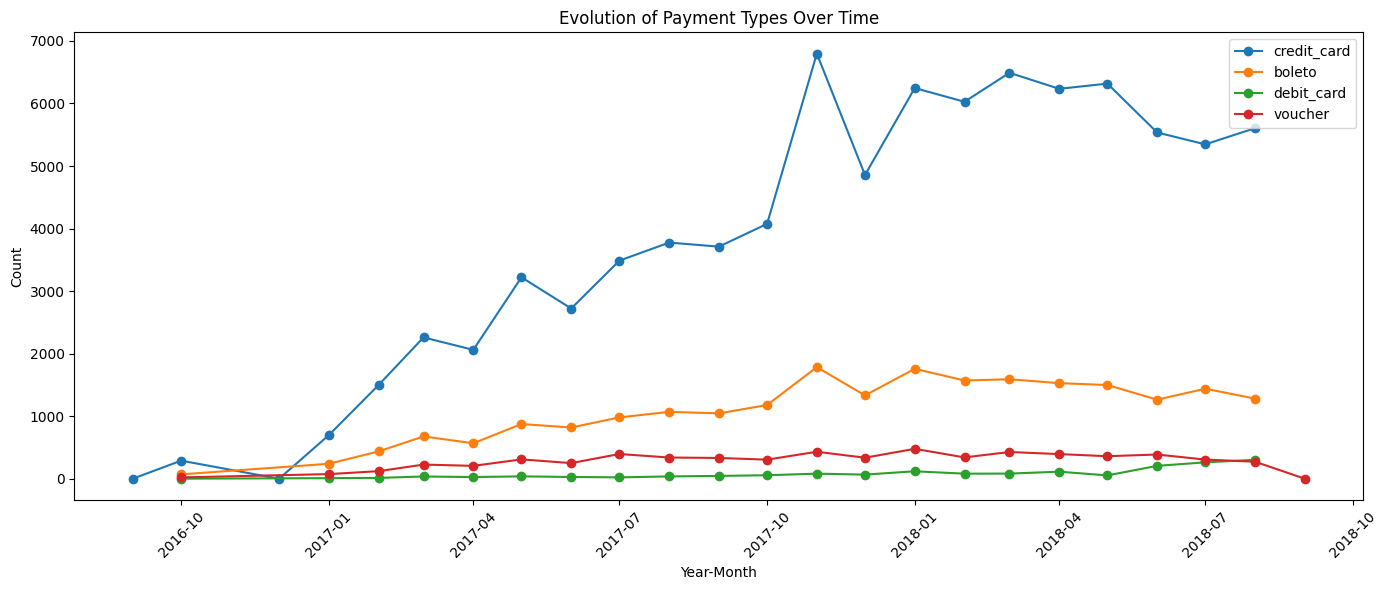

In [41]:
# Show the evolution of payment types over time

payment_by_time = df.groupby(['year_month', 'payment_type']).size().reset_index(name='count')
payment_by_time['year_month'] = pd.to_datetime(payment_by_time['year_month'])
payment_by_time = payment_by_time.sort_values('year_month')

plt.figure(figsize=(14, 6))
for payment_type in payment_by_time['payment_type'].unique():
    data = payment_by_time[payment_by_time['payment_type'] == payment_type]
    plt.plot(data['year_month'], data['count'], marker='o', label=payment_type)
plt.title('Evolution of Payment Types Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [42]:
print('hello')

hello


### 3 - Geolocation

In [46]:
df[['order_id', 'customer_zip_code_prefix']]

,order_id,customer_zip_code_prefix
0,e481f51cbdc54678b7cc49136f2d6af7,3149
1,e481f51cbdc54678b7cc49136f2d6af7,3149
2,e481f51cbdc54678b7cc49136f2d6af7,3149
3,53cdb2fc8bc7dce0b6741e2150273451,47813
4,47770eb9100c2d0c44946d9cf07ec65d,75265
...,...,...
118305,63943bddc261676b46f01ca7ac2f7bd8,11722
118306,83c1379a015df1e13d02aae0204711ab,45920
118307,11c177c8e97725db2631073c19f07b62,28685
118308,11c177c8e97725db2631073c19f07b62,28685


In [43]:
df_geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1037,-23.545621,-46.639292
1,1046,-23.546081,-46.644820
2,1046,-23.546129,-46.642951
3,1041,-23.544392,-46.639499
4,1035,-23.541578,-46.641607
...,...,...,...
1000158,99950,-28.068639,-52.010705
1000159,99900,-27.877125,-52.224882
1000160,99950,-28.071855,-52.014716
1000161,99980,-28.388932,-51.846871


In [ ]:
orders_with_geo = df[['order_id', 'customer_zip_code_prefix']].merge(df_geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first'), 
                               left_on='customer_zip_code_prefix', 
                               right_on='geolocation_zip_code_prefix', 
                               how='left')

In [ ]:
# Create a heatmap of all orders by location using an API to retrieve the latitude and longitude of every location, and display them on a map

# Verify required columns exist
required_columns = ['customer_zip_code_prefix']
if not all(col in df.columns for col in required_columns):
    print(f"Missing columns in df: {[col for col in required_columns if col not in df.columns]}")
    print(f"Available columns: {df.columns.tolist()}")
else:
    # Merge with geolocation data to get coordinates
    orders_with_geo = df.merge(df_geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first'), 
                               left_on='customer_zip_code_prefix', 
                               right_on='geolocation_zip_code_prefix', 
                               how='left')
    
    # Create a heatmap-style scatter plot
    plt.figure(figsize=(14, 8))
    orders_with_geo_clean = orders_with_geo.dropna(subset=['geolocation_lng', 'geolocation_lat'])
    
    if len(orders_with_geo_clean) > 0:
        plt.scatter(orders_with_geo_clean['geolocation_lng'], 
                   orders_with_geo_clean['geolocation_lat'], 
                   alpha=0.5, s=1)
        plt.title('Heatmap of Orders by Location')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.tight_layout()
        plt.show()
        print(f"Plotted {len(orders_with_geo_clean)} orders with valid coordinates")
    else:
        print("No valid coordinates found after filtering")

### 4 - Profit computation

In [ ]:
# Show the monthly profit evolution for the best 4 product categories
# x axis: months
# y axis: gross profit (payment value - total order value)
# hue : top product categories

# Calculate gross profit
df['gross_profit'] = df['payment_value'] - df['price']

# Get the top 4 product categories by total sales
top_categories = df.groupby('product_category_name')['payment_value'].sum().nlargest(4).index
df_top = df[df['product_category_name'].isin(top_categories)]

# Calculate monthly profit for top categories
profit_by_month_category = df_top.groupby(['year_month', 'product_category_name'])['gross_profit'].sum().reset_index()
profit_by_month_category['year_month'] = pd.to_datetime(profit_by_month_category['year_month'])
profit_by_month_category = profit_by_month_category.sort_values('year_month')

# Create the visualization
plt.figure(figsize=(14, 6))
for category in top_categories:
    data = profit_by_month_category[profit_by_month_category['product_category_name'] == category]
    plt.plot(data['year_month'], data['gross_profit'], marker='o', label=category)
plt.title('Monthly Profit Evolution for Top 4 Product Categories')
plt.xlabel('Year-Month')
plt.ylabel('Gross Profit')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
